# Customer Segmentation — Modelling
## Data Mining & Machine Learning | February 2026

**Sprint:** 3 | **User Stories:** US-4.1, US-4.2, US-4.3, US-4.4

---

### Notebook Objectives
1. Baseline K-Means(k=2) (US-4.1)
2. K-Means with Elbow + Silhouette selection (US-4.2)
3. Hierarchical Clustering with dendrogram (US-4.3)
4. DBSCAN with grid search (US-4.4)
5. Save all models to `models/`

## Section 1 — Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from scipy.cluster.hierarchy import dendrogram, linkage

from src.clustering import (
    find_optimal_k, run_kmeans, run_hierarchical,
    dbscan_grid_search, run_dbscan, save_model
)

sns.set_theme(style='whitegrid')
PROCESSED_DIR = '../data/processed'
MODELS_DIR    = '../models'
FIGURES_DIR   = '../figures'

# Load preprocessed data
X       = np.load(f'{PROCESSED_DIR}/X_scaled.npy')
X_nd    = np.load(f'{PROCESSED_DIR}/X_pca_n85.npy')
X_2d    = np.load(f'{PROCESSED_DIR}/X_pca2d.npy')
df_eng  = pd.read_csv(f'{PROCESSED_DIR}/df_cleaned.csv')

print(f'X shape (full scaled):  {X.shape}')
print(f'X_nd shape (PCA n85):   {X_nd.shape}')
print(f'X_2d shape (PCA 2D):    {X_2d.shape}')
print(f'df_eng shape:           {df_eng.shape}')

X shape (full scaled):  (2208, 24)
X_nd shape (PCA n85):   (2208, 9)
X_2d shape (PCA 2D):    (2208, 2)
df_eng shape:           (2208, 39)


## Section 2 — Baseline Model (US-4.1)

In [2]:
# Baseline: KMeans(k=2) — simplest viable clustering
baseline_model, baseline_labels, baseline_metrics = run_kmeans(X, n_clusters=2)

print('=== Baseline KMeans(k=2) ===')
for k, v in baseline_metrics.items():
    print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')

# Store for comparison table in 04_Evaluation
joblib.dump({'labels': baseline_labels, 'metrics': baseline_metrics},
            f'{MODELS_DIR}/baseline_results.pkl')

=== Baseline KMeans(k=2) ===
  n_clusters: 2
  silhouette: 0.2298
  davies_bouldin: 1.6603
  calinski_harabasz: 745.1851


['../models/baseline_results.pkl']

## Section 3 — K-Means: Optimal k Selection (US-4.2)

In [3]:
# Find optimal k via Elbow + Silhouette
k_results = find_optimal_k(X, k_range=range(2, 13))
print(k_results.round(4).to_string(index=False))

 k    inertia  silhouette  davies_bouldin  calinski_harabasz
 2 25397.0038      0.2298          1.6603           745.1851
 3 22527.3098      0.1770          1.8878           560.3103
 4 21009.8495      0.1450          2.0621           453.4000
 5 19864.6644      0.1413          2.0430           391.2409
 6 19165.7547      0.1317          2.1453           340.3191
 7 18550.8391      0.1226          2.1362           305.0265
 8 18017.2759      0.1076          2.3525           278.3788
 9 17538.1491      0.1073          2.2465           257.6315
10 17250.0796      0.1042          2.3169           236.8026
11 16887.3802      0.1024          2.3045           222.3193
12 16651.2829      0.0964          2.3222           207.7114


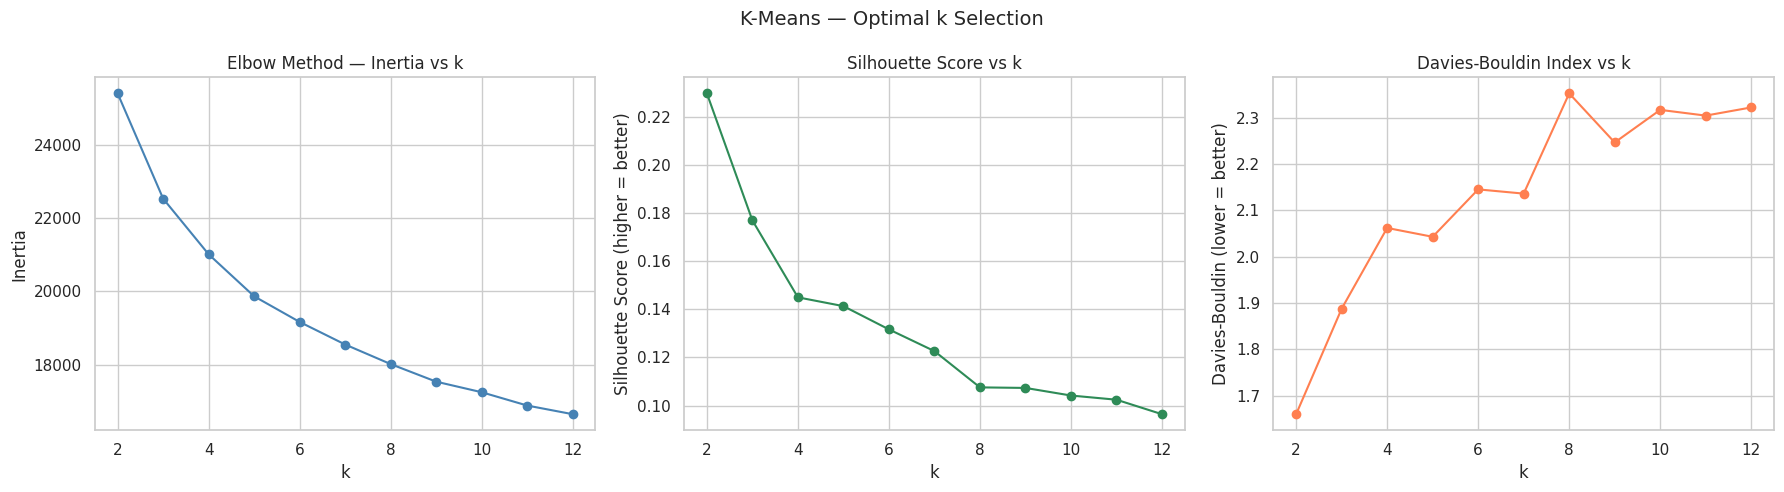

In [4]:
# Plot Elbow + Silhouette side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Elbow
axes[0].plot(k_results['k'], k_results['inertia'], marker='o', color='steelblue')
axes[0].set_title('Elbow Method — Inertia vs k')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].grid(True)

# Silhouette
axes[1].plot(k_results['k'], k_results['silhouette'], marker='o', color='seagreen')
axes[1].set_title('Silhouette Score vs k')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score (higher = better)')
axes[1].grid(True)

# Davies-Bouldin
axes[2].plot(k_results['k'], k_results['davies_bouldin'], marker='o', color='coral')
axes[2].set_title('Davies-Bouldin Index vs k')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Davies-Bouldin (lower = better)')
axes[2].grid(True)

plt.suptitle('K-Means — Optimal k Selection', fontsize=14)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/kmeans_k_selection.png', dpi=150)
plt.show()

In [5]:
# Select optimal k — pick from plot above
# Default: k where silhouette peaks and elbow inflects
OPTIMAL_K = int(k_results.loc[k_results['silhouette'].idxmax(), 'k'])
print(f'Selected optimal k: {OPTIMAL_K}')
print(f'Silhouette at k={OPTIMAL_K}: {k_results[k_results.k == OPTIMAL_K].silhouette.values[0]:.4f}')

Selected optimal k: 2
Silhouette at k=2: 0.2298


In [6]:
# Fit final K-Means with optimal k
km_model, km_labels, km_metrics = run_kmeans(X, n_clusters=OPTIMAL_K)

print(f'=== K-Means (k={OPTIMAL_K}) ===')
for k, v in km_metrics.items():
    print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')

# Save
save_model(km_model, f'{MODELS_DIR}/kmeans.pkl')
np.save(f'{MODELS_DIR}/kmeans_labels.npy', km_labels)
print(f'\nModel saved to models/kmeans.pkl')

=== K-Means (k=2) ===
  n_clusters: 2
  silhouette: 0.2298
  davies_bouldin: 1.6603
  calinski_harabasz: 745.1851

Model saved to models/kmeans.pkl


## Section 4 — Hierarchical Clustering with Dendrogram (US-4.3)

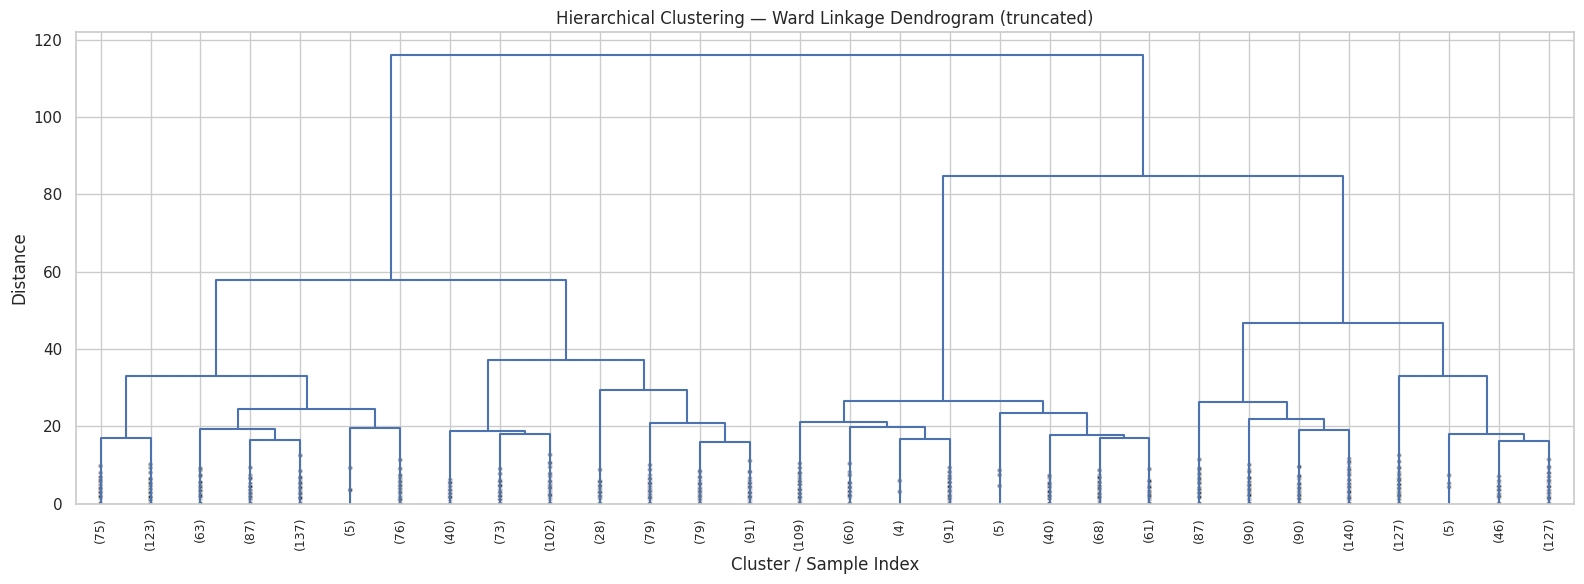

In [7]:
# Plot dendrogram (Ward linkage, truncated to last 30 merges)
linked = linkage(X, method='ward')

plt.figure(figsize=(16, 6))
dendrogram(linked, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=9,
           show_contracted=True, color_threshold=0)
plt.title('Hierarchical Clustering — Ward Linkage Dendrogram (truncated)')
plt.xlabel('Cluster / Sample Index')
plt.ylabel('Distance')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/dendrogram.png', dpi=150)
plt.show()

In [8]:
# Select n_clusters from dendrogram — look for largest vertical gap
# Update HIER_K based on visual inspection of dendrogram above
HIER_K = OPTIMAL_K  # start with same as KMeans; adjust if dendrogram suggests otherwise
print(f'Hierarchical n_clusters: {HIER_K}')

hier_model, hier_labels, hier_metrics = run_hierarchical(X, n_clusters=HIER_K)

print(f'\n=== Hierarchical Clustering (k={HIER_K}) ===')
for k, v in hier_metrics.items():
    print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')

# Save
save_model(hier_model, f'{MODELS_DIR}/hierarchical.pkl')
np.save(f'{MODELS_DIR}/hierarchical_labels.npy', hier_labels)
print('Model saved to models/hierarchical.pkl')

Hierarchical n_clusters: 2

=== Hierarchical Clustering (k=2) ===
  n_clusters: 2
  silhouette: 0.1797
  davies_bouldin: 1.9428
  calinski_harabasz: 546.2830
Model saved to models/hierarchical.pkl


## Section 5 — DBSCAN Grid Search & Tuning (US-4.4)

In [9]:
# Grid search on PCA-reduced data to mitigate curse of dimensionality
print('Running DBSCAN grid search on PCA-reduced data...')
gs_results = dbscan_grid_search(X_nd)

print(f'Grid search complete — {len(gs_results)} combinations tested')
print()
# Show combinations with noise < 15% and n_clusters >= 2
valid = gs_results[(gs_results['noise_pct'] < 15) & (gs_results['n_clusters'] >= 2)]
print(f'Valid combinations (noise < 15%, clusters >= 2): {len(valid)}')
print(valid.sort_values('silhouette', ascending=False).head(10).round(4).to_string(index=False))

Running DBSCAN grid search on PCA-reduced data...
Grid search complete — 20 combinations tested

Valid combinations (noise < 15%, clusters >= 2): 0
Empty DataFrame
Columns: [eps, min_samples, n_clusters, noise_pct, silhouette]
Index: []


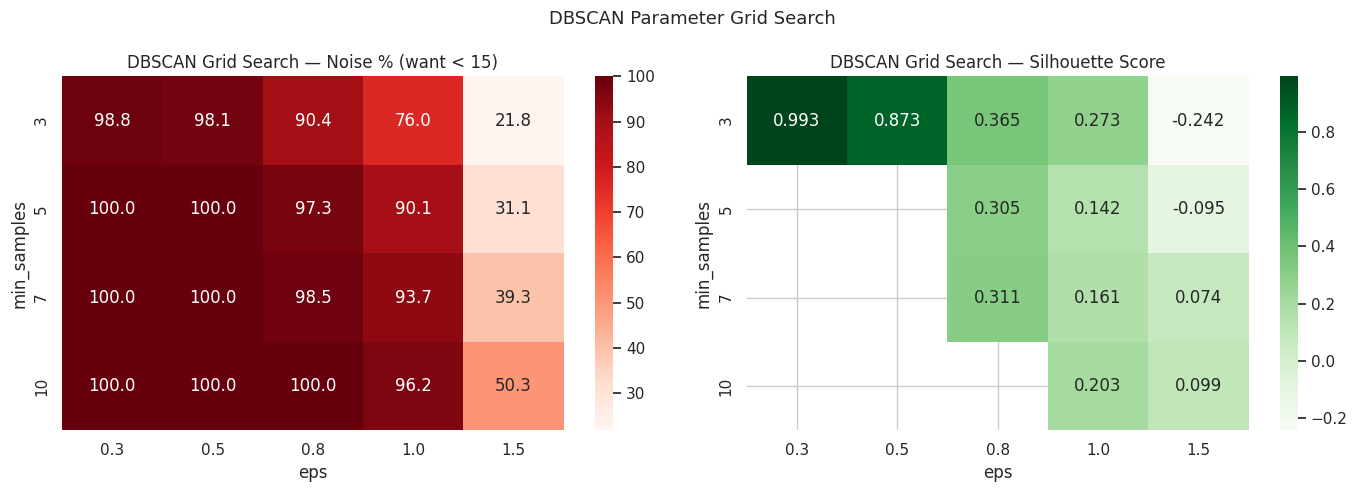

In [10]:
# Visualise grid search results
pivot_noise = gs_results.pivot(index='min_samples', columns='eps', values='noise_pct')
pivot_sil   = gs_results.pivot(index='min_samples', columns='eps', values='silhouette')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(pivot_noise, annot=True, fmt='.1f', cmap='Reds', ax=axes[0])
axes[0].set_title('DBSCAN Grid Search — Noise % (want < 15)')

sns.heatmap(pivot_sil, annot=True, fmt='.3f', cmap='Greens', ax=axes[1])
axes[1].set_title('DBSCAN Grid Search — Silhouette Score')

plt.suptitle('DBSCAN Parameter Grid Search', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/dbscan_grid_search.png', dpi=150)
plt.show()

In [11]:
# Select best DBSCAN params
if len(valid) > 0:
    best_row = valid.sort_values('silhouette', ascending=False).iloc[0]
    BEST_EPS = best_row['eps']
    BEST_MS  = int(best_row['min_samples'])
else:
    # Fallback defaults
    BEST_EPS, BEST_MS = 0.8, 5
    print('WARNING: No valid DBSCAN params found — using fallback (eps=0.8, min_samples=5)')

print(f'Selected: eps={BEST_EPS}, min_samples={BEST_MS}')

db_model, db_labels, db_metrics = run_dbscan(X_nd, eps=BEST_EPS, min_samples=BEST_MS)
noise_pct = round((db_labels == -1).sum() / len(db_labels) * 100, 2)

print(f'\n=== DBSCAN (eps={BEST_EPS}, min_samples={BEST_MS}) ===')
for k, v in db_metrics.items():
    print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')
print(f'  noise_pct: {noise_pct}%')

save_model(db_model, f'{MODELS_DIR}/dbscan.pkl')
np.save(f'{MODELS_DIR}/dbscan_labels.npy', db_labels)
print('Model saved to models/dbscan.pkl')

Selected: eps=0.8, min_samples=5

=== DBSCAN (eps=0.8, min_samples=5) ===
  n_clusters: 6
  silhouette: 0.3047
  davies_bouldin: 1.0041
  calinski_harabasz: 22.9264
  noise_pct: 97.33%
Model saved to models/dbscan.pkl


## Section 6 — Models Saved

| Model | File | n_clusters |
|---|---|---|
| Baseline KMeans(k=2) | `models/baseline_results.pkl` | 2 |
| K-Means (optimal k) | `models/kmeans.pkl` + `kmeans_labels.npy` | OPTIMAL_K |
| Hierarchical (Ward) | `models/hierarchical.pkl` + `hierarchical_labels.npy` | HIER_K |
| DBSCAN (best params) | `models/dbscan.pkl` + `dbscan_labels.npy` | auto |

> All models trained. Proceed to `04_Evaluation.ipynb` for metric comparison,
> PCA scatter plots, cluster profiling, and persona assignment.